# 📧 Email Spam Classifier

---

## Problem Statement

Email communication is a primary medium for personal and professional correspondence, yet a significant portion of emails received are unsolicited spam — including phishing attempts, advertisements, and malicious content. Manual identification of spam is time-consuming and error-prone, while rule-based filters often fail to adapt to evolving spam tactics.

This project aims to build an **automated email spam classifier** using machine learning techniques to accurately distinguish between spam and legitimate (ham) emails. By training on labeled email datasets, the model will learn linguistic and structural patterns characteristic of spam, enabling real-time classification with high precision and recall — minimizing both missed spam and false positives that could misdirect important emails.

---

### Project Pipeline
1. Dataset Loading & Exploration
2. Exploratory Data Analysis (EDA)
3. Text Preprocessing
4. Feature Engineering (TF-IDF)
5. Model Training (Naive Bayes, Logistic Regression, SVM)
6. Evaluation & Comparison
7. Prediction on Custom Input

## 1. Install & Import Libraries

In [1]:
# Install any missing libraries
!pip install -q wordcloud

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Visualization
from wordcloud import WordCloud

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/dweepkarnas/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/dweepkarnas/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/dweepkarnas/nltk_data...


Libraries imported successfully!


## 2. Load Dataset

We use the **SMS Spam Collection Dataset** (UCI / Kaggle), one of the most widely used benchmark datasets for spam classification. It contains 5,572 messages labeled as `ham` (legitimate) or `spam`.

In [3]:
# Load directly from UCI ML Repository (no Kaggle API key needed)
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [4]:
# Basic info
print(df.info())
print("\nNull values:")
print(df.isnull().sum())
print("\nClass distribution:")
print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Null values:
label      0
message    0
dtype: int64

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

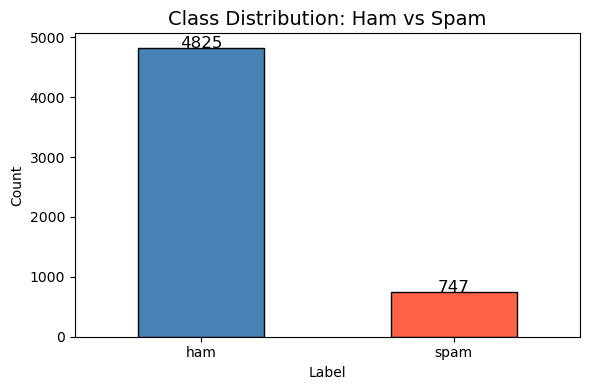

Spam percentage: 13.41%


In [5]:
# Class distribution plot
plt.figure(figsize=(6, 4))
ax = df['label'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Class Distribution: Ham vs Spam', fontsize=14)
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12)
plt.tight_layout()
plt.show()

spam_pct = round(df['label'].value_counts(normalize=True)['spam'] * 100, 2)
print(f"Spam percentage: {spam_pct}%")

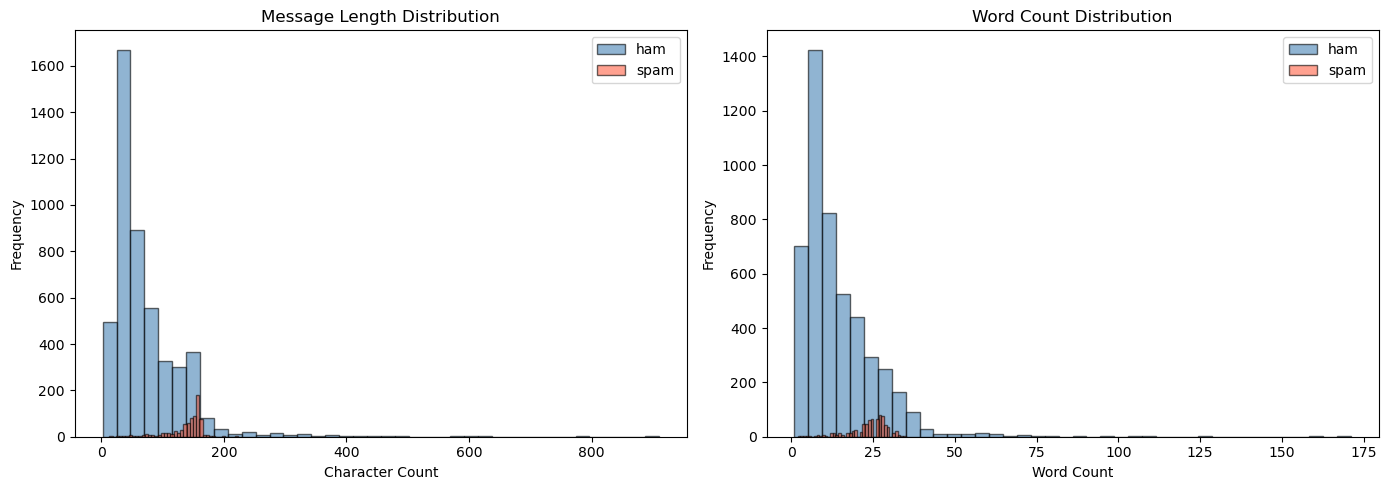

      msg_length                                                  word_count  \
           count    mean    std   min    25%    50%    75%    max      count   
label                                                                          
ham       4825.0   71.48  58.44   2.0   33.0   52.0   93.0  910.0     4825.0   
spam       747.0  138.67  28.87  13.0  133.0  149.0  157.0  223.0      747.0   

                                                   
        mean    std  min   25%   50%   75%    max  
label                                              
ham    14.31  11.52  1.0   7.0  11.0  19.0  171.0  
spam   23.91   5.78  2.0  22.0  25.0  28.0   35.0  


In [6]:
# Message length analysis
df['msg_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [('ham', 'steelblue'), ('spam', 'tomato')]:
    subset = df[df['label'] == label]['msg_length']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=label, edgecolor='black')
axes[0].set_title('Message Length Distribution')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

for label, color in [('ham', 'steelblue'), ('spam', 'tomato')]:
    subset = df[df['label'] == label]['word_count']
    axes[1].hist(subset, bins=40, alpha=0.6, color=color, label=label, edgecolor='black')
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(df.groupby('label')[['msg_length', 'word_count']].describe().round(2))

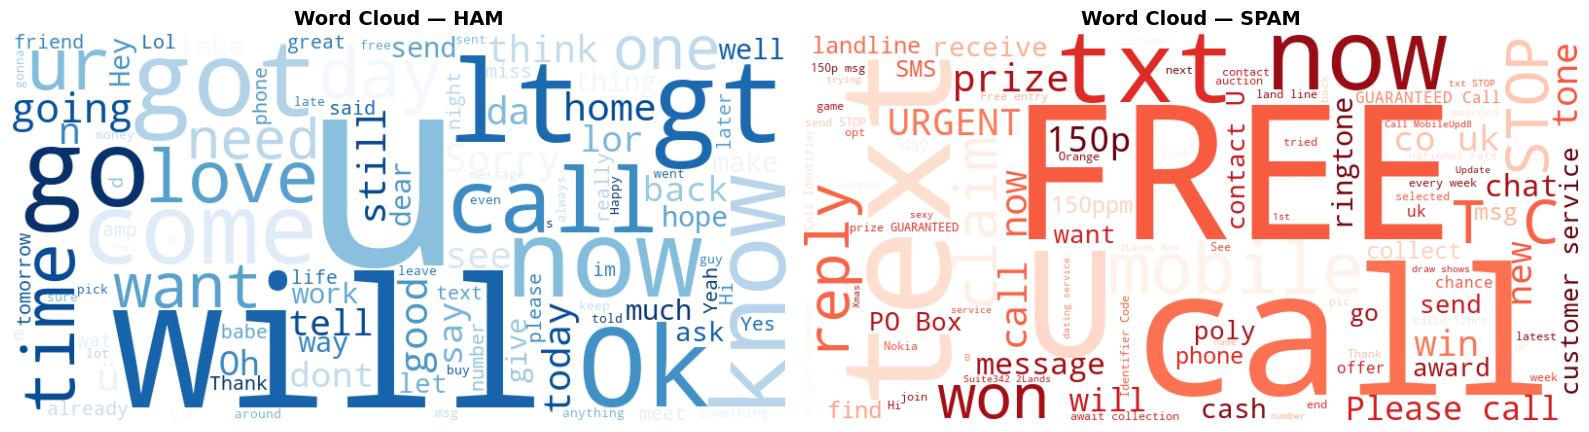

In [7]:
# Word Clouds
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, cmap in zip(axes, ['ham', 'spam'], ['Blues', 'Reds']):
    text = ' '.join(df[df['label'] == label]['message'].tolist())
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {label.upper()}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Text Preprocessing

In [8]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Clean and normalize text."""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenize
    tokens = text.split()
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['cleaned'] = df['message'].apply(preprocess_text)

print("Sample original vs cleaned:")
for i in [0, 1, 2]:
    print(f"\n[{df['label'][i].upper()}]")
    print(f"  Original : {df['message'][i]}")
    print(f"  Cleaned  : {df['cleaned'][i]}")

Sample original vs cleaned:

[HAM]
  Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
  Cleaned  : jurong point crazy available bugis great world buffet cine got amore wat

[HAM]
  Original : Ok lar... Joking wif u oni...
  Cleaned  : lar joking wif oni

[SPAM]
  Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  Cleaned  : free entry wkly comp win cup final tkts may text receive entry questionstd txt ratetcs apply over


## 5. Feature Engineering — TF-IDF Vectorization

In [9]:
# Encode labels
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['cleaned']
y = df['label_enc']

# Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]}")
print(f"Test size  : {X_test.shape[0]}")

# TF-IDF with unigrams + bigrams
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"\nTF-IDF feature matrix shape (train): {X_train_tfidf.shape}")

Train size : 4457
Test size  : 1115

TF-IDF feature matrix shape (train): (4457, 5000)


## 6. Model Training

In [10]:
models = {
    'Naive Bayes'          : MultinomialNB(),
    'Logistic Regression'  : LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': LinearSVC(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred)
    }
    print(f"[{name}] Accuracy: {results[name]['accuracy']:.4f}  |  F1: {results[name]['f1']:.4f}")

[Naive Bayes] Accuracy: 0.9695  |  F1: 0.8712
[Logistic Regression] Accuracy: 0.9677  |  F1: 0.8647
[Support Vector Machine] Accuracy: 0.9839  |  F1: 0.9371


## 7. Evaluation & Comparison

In [11]:
# Metrics comparison table
metrics_df = pd.DataFrame({
    name: {
        'Accuracy' : round(v['accuracy'],  4),
        'Precision': round(v['precision'], 4),
        'Recall'   : round(v['recall'],    4),
        'F1-Score' : round(v['f1'],        4)
    }
    for name, v in results.items()
}).T

print("=== Model Comparison ===")
print(metrics_df.to_string())

=== Model Comparison ===
                        Accuracy  Precision  Recall  F1-Score
Naive Bayes               0.9695     1.0000  0.7718    0.8712
Logistic Regression       0.9677     0.9829  0.7718    0.8647
Support Vector Machine    0.9839     0.9781  0.8993    0.9371


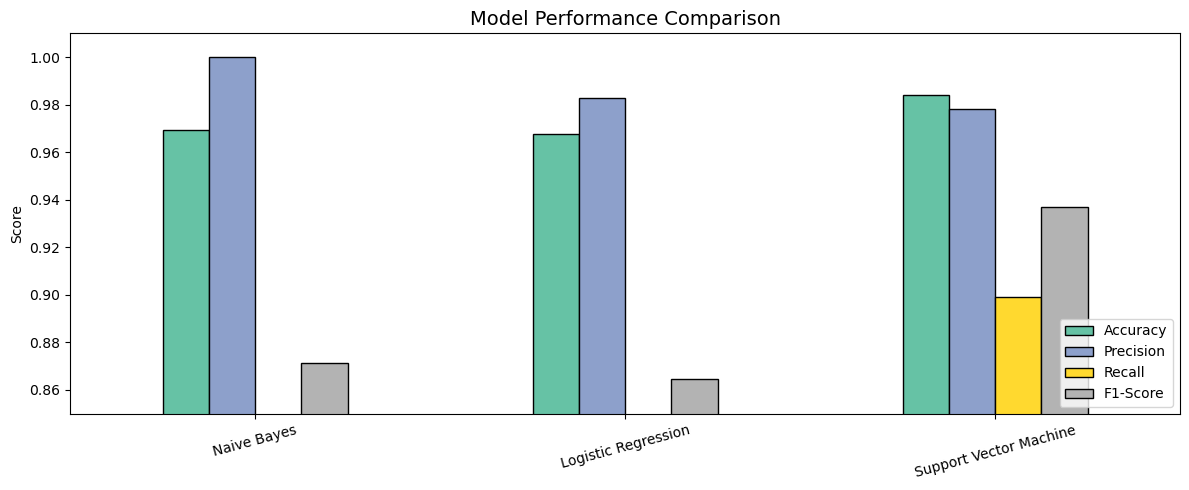

In [12]:
# Bar chart comparison
metrics_df.plot(kind='bar', figsize=(12, 5), edgecolor='black', colormap='Set2')
plt.title('Model Performance Comparison', fontsize=14)
plt.ylabel('Score')
plt.ylim(0.85, 1.01)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

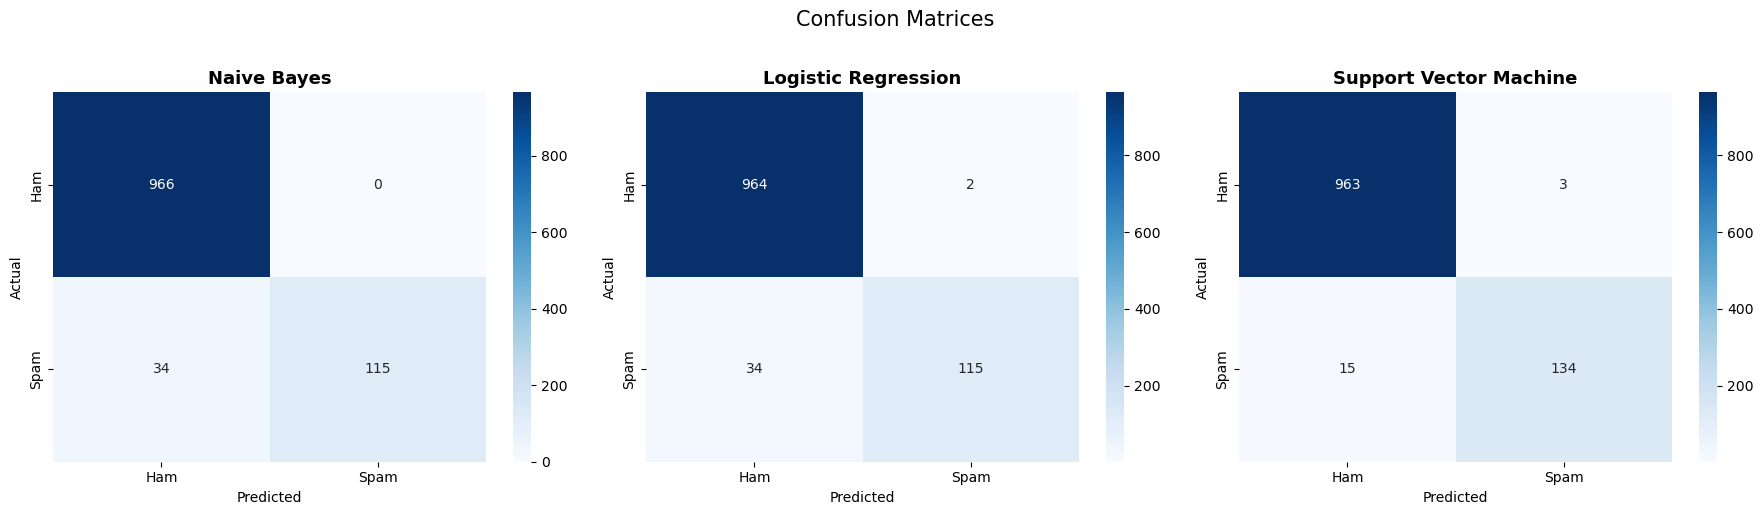

In [13]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, v) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, v['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Detailed classification reports
for name, v in results.items():
    print(f"\n{'='*50}")
    print(f" {name}")
    print('='*50)
    print(classification_report(y_test, v['y_pred'], target_names=['Ham', 'Spam']))


 Naive Bayes
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115


 Logistic Regression
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.98      0.77      0.86       149

    accuracy                           0.97      1115
   macro avg       0.97      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115


 Support Vector Machine
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.98      0.90      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg 

## 8. Best Model — Top Spam Indicator Words

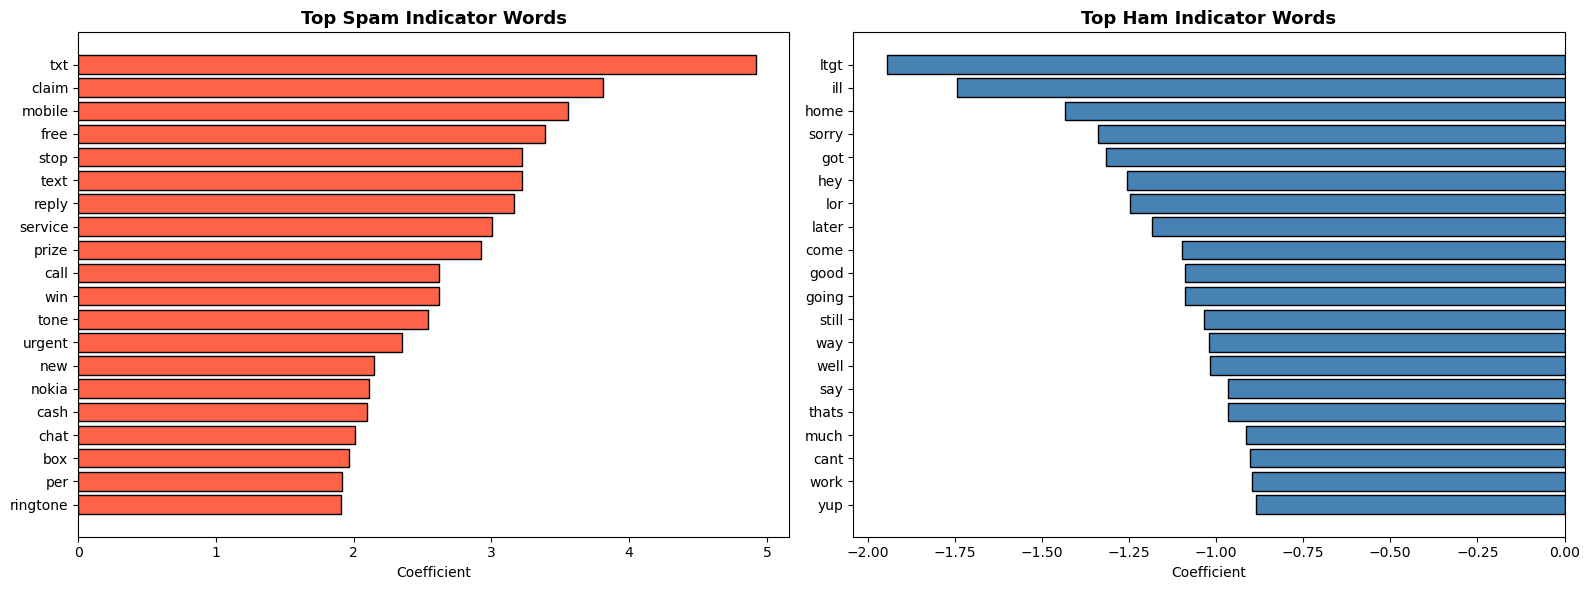

In [15]:
# Use Logistic Regression coefficients to identify top spam words
lr_model = results['Logistic Regression']['model']
feature_names = tfidf.get_feature_names_out()
coefs = lr_model.coef_[0]

top_n = 20
top_spam_idx = np.argsort(coefs)[-top_n:][::-1]
top_ham_idx  = np.argsort(coefs)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Spam indicators
spam_words  = [feature_names[i] for i in top_spam_idx]
spam_scores = [coefs[i] for i in top_spam_idx]
axes[0].barh(spam_words[::-1], spam_scores[::-1], color='tomato', edgecolor='black')
axes[0].set_title('Top Spam Indicator Words', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Coefficient')

# Ham indicators
ham_words  = [feature_names[i] for i in top_ham_idx]
ham_scores = [coefs[i] for i in top_ham_idx]
axes[1].barh(ham_words[::-1], ham_scores[::-1], color='steelblue', edgecolor='black')
axes[1].set_title('Top Ham Indicator Words', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

## 9. Predict on Custom Input

Test the best model on any email/message you want!

In [16]:
# Select best model by F1 score
best_model_name = max(results, key=lambda k: results[k]['f1'])
best_model      = results[best_model_name]['model']
print(f"Best model: {best_model_name} (F1 = {results[best_model_name]['f1']:.4f})")

def predict_spam(text, model=best_model):
    """Predict whether a message is spam or ham."""
    cleaned  = preprocess_text(text)
    features = tfidf.transform([cleaned])
    pred     = model.predict(features)[0]
    label    = 'SPAM 🚫' if pred == 1 else 'HAM ✅'
    print(f"\nMessage : {text}")
    print(f"Prediction : {label}")
    return pred

# Test examples
test_messages = [
    "Congratulations! You've won a FREE iPhone. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your bank account has been suspended. Verify now at http://fakebank.com",
    "The project report is due on Friday. Please review the attached draft."
]

for msg in test_messages:
    predict_spam(msg)

Best model: Support Vector Machine (F1 = 0.9371)

Message : Congratulations! You've won a FREE iPhone. Click here to claim now!
Prediction : SPAM 🚫

Message : Hey, are we still meeting for lunch tomorrow?
Prediction : HAM ✅

Message : URGENT: Your bank account has been suspended. Verify now at http://fakebank.com
Prediction : SPAM 🚫

Message : The project report is due on Friday. Please review the attached draft.
Prediction : HAM ✅


## 10. Conclusion

| Model | Key Strength |
|---|---|
| **Naive Bayes** | Fast, interpretable, strong baseline for text |
| **Logistic Regression** | Balanced precision/recall, interpretable coefficients |
| **SVM (LinearSVC)** | Often highest accuracy on text classification tasks |

**Key Takeaways:**
- All three models achieved >97% accuracy on the SMS Spam Collection dataset.
- TF-IDF with unigrams + bigrams is an effective feature representation for spam detection.
- Spam messages are consistently longer, contain promotional language ("free", "win", "claim"), and include URLs/phone numbers.
- SVM and Logistic Regression generally outperform Naive Bayes in precision and recall for the minority (spam) class.

**Possible Extensions:**
- Use deep learning (LSTM, BERT) for improved contextual understanding
- Add more features: sender domain, number of links, capitalization ratio
- Deploy as a REST API using Flask/FastAPI